## MP5 - pDC subppopulation DEA

MP5 (Healthy-derived) scoring revealed what looks like two subpopulations within pDCs. \
This script: \
    1. subsets to Healthy cells only, cell type = pDCs \
    2. splits those cells by HIHA_MP5_score at a threshold of 1.0 (>= 1.0 = "MP5_high", < 1.0 = "MP5_low") \
    3. runs a Wilcoxon DEG test between the two groups
 
Method: sc.tl.rank_genes_groups, Wilcoxon rank-sum test, use_raw=False - same convention used for DEG comparisons elsewhere in this project.

In [2]:
import os
os.environ['TZ'] = 'Europe/Berlin'
 
import re
 
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import gseapy as gp

In [ ]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
mp_scores = pd.read_csv(f"{BASE}/results/09_HIHAtlas/09_03_nmf_downsampled/mp_scores_healthy.csv", index_col=0)
adata = sc.read_h5ad(f"{BASE}/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad")
print("Loaded:", adata.shape)
print(adata.obs.columns.tolist())
print("Loaded original NMF scores:", mp_scores.shape, mp_scores.columns.tolist())


Loaded: (208945, 22586)
['donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score', 'dataset', 'dataset_batch']
Loaded original NMF scores: (129435, 8) ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score']


In [14]:
mp_scores.head(10)

,MP1_score,MP2_score,MP3_score,MP4_score,MP5_score,MP6_score,MP7_score,MP8_score
barcodes,,,,,,,,
74fc381648b611eabab7c676ab45cfca,-0.090854,-0.523981,-0.531879,-0.093201,0.566022,-0.616668,-0.166547,0.199721
5cfdece648b111ea8fbed2ddb8e0a14a,-0.138964,-0.376928,-0.471963,-0.092312,0.602548,-0.650284,-0.145765,0.216961
6cfb85c848b511ea87c666a4322bd84a,-0.036029,-0.479844,-0.592716,-0.044581,0.614911,-0.633519,-0.159706,0.226616
54b6da1e495311ea86cade558b2f8879,-0.292412,-0.537504,-0.638312,-0.146883,1.129584,-0.623997,-0.142083,0.142925
54cdf6ae495311ea86cade558b2f8879,0.160440,-0.489670,-0.583046,-0.104478,0.194279,-0.620163,-0.181035,0.281437
deed398c48cf11eaacaa42cd98cbd24e,0.087413,-0.324105,-0.395248,-0.116565,0.396212,-0.571174,-0.099980,0.224932
def10a2648cf11eaacaa42cd98cbd24e,0.052091,-0.434396,-0.589313,-0.088747,0.461352,-0.608794,-0.162717,0.255518
70d4325c48b611eaa65d9e7d578d66f2,0.069879,-0.596430,-0.472956,-0.112867,0.164265,-0.647771,-0.111103,0.249194
c680bf5c48bd11eab2ee7a6edf799b61,-0.147246,-0.397147,-0.581725,-0.086223,0.964112,-0.610148,-0.097280,0.228602


In [21]:
if "condition" in adata.obs.columns:
    condition_col = "condition"
elif "dataset" in adata.obs.columns:
    label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
    adata.obs["condition"] = adata.obs["dataset"].map(label_map)
    condition_col = "condition"
else:
    raise ValueError(
        "Neither 'condition' nor 'dataset' found in adata.obs. Inspect "
        "obs columns and set the grouping column manually."
    )
print(f"Using condition column: '{condition_col}'")

Using condition column: 'condition'


In [23]:
print("Loaded original NMF scores:", mp_scores.shape, mp_scores.columns.tolist())
 
score_cols_native = [c for c in mp_scores.columns if re.match(r"MP\d+_score$", c)]
if not score_cols_native:
    raise ValueError(
        f"No MPX_score columns found in {mp_scores}. "
        f"Columns present: {mp_scores.columns.tolist()}"
    )
 

Loaded original NMF scores: (129435, 8) ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score']


In [24]:
healthy_mask = adata.obs[condition_col] == "Healthy"
print("Sample adata (Healthy) barcodes:", adata.obs_names[healthy_mask][:5].tolist())
print("Sample mp_scores_healthy.csv barcodes:", mp_scores.index[:5].tolist())

Sample adata (Healthy) barcodes: ['74fc381648b611eabab7c676ab45cfca-HIHAtlas', '5cfdece648b111ea8fbed2ddb8e0a14a-HIHAtlas', '6cfb85c848b511ea87c666a4322bd84a-HIHAtlas', '54b6da1e495311ea86cade558b2f8879-HIHAtlas', '54cdf6ae495311ea86cade558b2f8879-HIHAtlas']
Sample mp_scores_healthy.csv barcodes: ['74fc381648b611eabab7c676ab45cfca', '5cfdece648b111ea8fbed2ddb8e0a14a', '6cfb85c848b511ea87c666a4322bd84a', '54b6da1e495311ea86cade558b2f8879', '54cdf6ae495311ea86cade558b2f8879']


In [25]:
adata_barcodes_stripped = adata.obs_names.str.replace(r"-HIHAtlas$", "", regex=True)
 
aligned = mp_scores[score_cols_native].reindex(adata_barcodes_stripped)
aligned.index = adata.obs_names  # restore original index for assignment below
n_missing = aligned.isna().all(axis=1).sum()
print(f"{n_missing} of {adata.n_obs} cells in adata have no matching barcode in the original NMF scores after suffix-stripping (some non-Healthy/GBM cells are expected to not match at all, since mp_scores_healthy.csv only ever covered Healthy cells)")
 
for col in score_cols_native:
    adata.obs[col] = aligned[col].values

79510 of 208945 cells in adata have no matching barcode in the original NMF scores after suffix-stripping (some non-Healthy/GBM cells are expected to not match at all, since mp_scores_healthy.csv only ever covered Healthy cells)


In [26]:
# ---- 3. find the MP5 score column just merged in ----
mp5_candidates = [c for c in adata.obs.columns if re.match(r"(HIHA_)?MP5_score$", c)]
if not mp5_candidates:
    raise ValueError(
        f"No MP5 score column found after merging. Columns available: "
        f"{score_cols_native}"
    )
mp5_col = mp5_candidates[0]
print(f"Using MP5 score column: '{mp5_col}'")

Using MP5 score column: 'MP5_score'


In [28]:
healthy_pdc = adata[
    (adata.obs[condition_col] == "Healthy") & (adata.obs["decoupler_level1_celltype"] == "pDC")
].copy()
print("Healthy pDC subset shape (before dropping unscored cells):", healthy_pdc.shape)
 
n_unscored = healthy_pdc.obs[mp5_col].isna().sum()
if n_unscored:
    print(f"Dropping {n_unscored} of {healthy_pdc.n_obs} Healthy pDCs with "
          f"no native MP5 score (not in the original NMF run)")
    healthy_pdc = healthy_pdc[healthy_pdc.obs[mp5_col].notna()].copy()
 
print("Healthy pDC subset shape (after dropping):", healthy_pdc.shape)
print(healthy_pdc.obs[mp5_col].describe())

Healthy pDC subset shape (before dropping unscored cells): (8738, 22586)
Healthy pDC subset shape (after dropping): (8738, 22586)
count    8738.000000
mean        0.686906
std         0.632427
min        -0.258562
25%        -0.011223
50%         1.056457
75%         1.262291
max         1.718315
Name: MP5_score, dtype: float64


In [29]:
THRESHOLD = 1.0
MIN_CELLS = 10


healthy_pdc.obs["MP5_group"] = pd.Categorical(
    (healthy_pdc.obs[mp5_col] >= THRESHOLD).map({True: "MP5_high", False: "MP5_low"}),
    categories=["MP5_low", "MP5_high"],
)
print(healthy_pdc.obs["MP5_group"].value_counts())
 
n_low = (healthy_pdc.obs["MP5_group"] == "MP5_low").sum()
n_high = (healthy_pdc.obs["MP5_group"] == "MP5_high").sum()
if n_low < MIN_CELLS or n_high < MIN_CELLS:
    raise ValueError(
        f"One group has too few cells for a reliable DEG test "
        f"(MP5_low={n_low}, MP5_high={n_high}, MIN_CELLS={MIN_CELLS}). "
        f"Consider adjusting THRESHOLD."
    )

MP5_group
MP5_high    4584
MP5_low     4154
Name: count, dtype: int64


In [30]:
print(f"X.min()={healthy_pdc.X.min():.3f}  X.max()={healthy_pdc.X.max():.3f}  "
      f"log1p flag={healthy_pdc.uns.get('log1p')}")

X.min()=0.000  X.max()=8.844  log1p flag=None


### DEG between MP5_high and MP5_low

In [31]:
sc.tl.rank_genes_groups(
    healthy_pdc,
    groupby="MP5_group",
    groups=["MP5_high"],
    reference="MP5_low",
    method="wilcoxon",
    use_raw=False,
)
 
deg_df = sc.get.rank_genes_groups_df(healthy_pdc, group="MP5_high")
out_csv = os.path.join(OUT_DIR, "10_09_deg_pDC_MP5_high_vs_low.csv")
deg_df.to_csv(out_csv, index=False)
print(f"\nSaved DEG results to {out_csv}")
 
print("\nTop 20 genes (by score, sign: positive = up in MP5_high):")
print(deg_df.sort_values("scores", ascending=False).head(20).to_string(index=False))


Saved DEG results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_DEG_pDC_MP5/deg_pDC_MP5_high_vs_low.csv

Top 20 genes (by score, sign: positive = up in MP5_high):
   names    scores  logfoldchanges  pvals  pvals_adj
    GZMB 78.118454        7.004508    0.0        0.0
PPP1R14B 77.468910        4.365202    0.0        0.0
   ITM2C 76.816925        4.029866    0.0        0.0
SERPINF1 76.767151        5.196849    0.0        0.0
    IRF7 76.634209        4.752818    0.0        0.0
  CCDC50 76.486877        3.500276    0.0        0.0
    UGCG 76.401100        4.358928    0.0        0.0
    NPC2 75.896011        3.661004    0.0        0.0
  SEC61B 75.535004        3.347940    0.0        0.0
C12orf75 74.805885        4.519783    0.0        0.0
   IL3RA 74.405022        4.742496    0.0        0.0
 ALOX5AP 74.095596        3.663618    0.0        0.0
  LILRA4 73.847511        4.851137    0.0        0.0
    PLD4 73.830925        3.812032    0.0 

### GSEA

In [5]:
deg_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_deg_pDC_MP5_high_vs_low.csv")
print("Loaded DEG results:", deg_df.shape)


Loaded DEG results: (22586, 5)


In [ ]:
GENE_SETS = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/c7.immunesigdb.v2026.1.Hs.symbols.gmt" # immuneSigDB
# GENE_SETS = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/c5.go.bp.v2026.1.Hs.symbols.gmt" # GO

GSEA_OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA/10_09_GSEA_pDC_MP5"
os.makedirs(GSEA_OUT_DIR, exist_ok=True)

In [7]:
rnk = deg_df[["names", "scores"]].sort_values("scores", ascending=False)
rnk.columns = ["gene_name", "Wilcoxon score"]
rnk = rnk.drop_duplicates("gene_name").set_index("gene_name")
print(f"Ranked gene list: {len(rnk)} genes")

Ranked gene list: 22586 genes


In [8]:
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=GENE_SETS,
    min_size=5,
    max_size=1000,
    permutation_num=1000,
    outdir=os.path.join(GSEA_OUT_DIR, "10_09_prerank_pDC_MP5_imSig"),
    seed=42,
    threads=4,
)
 
res_df = pre_res.res2d.copy()
out_csv = os.path.join(GSEA_OUT_DIR, "10_09_gsea_prerank_pDC:imSig.csv")
res_df.to_csv(out_csv, index=False)
print(f"Saved full GSEA results to {out_csv}")

2026-09-25 16:57:37,436 [WARNING] Duplicated values found in preranked stats: 32.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Saved full GSEA results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_GSEA_pDC_MP5/10_09_gsea_prerank_pDC:imSig.csv


In [9]:

FDR_CUTOFF = 0.05

sig = res_df[res_df["FDR q-val"] < FDR_CUTOFF].copy()
print(f"{len(sig)} significant terms at FDR<{FDR_CUTOFF}")
 
if sig.empty:
    raise SystemExit("No significant GSEA terms found - nothing to plot.")
 
sig["NES"] = sig["NES"].astype(float)
sig = sig.sort_values("NES")

224 significant terms at FDR<0.05


In [11]:
TOP_N_PER_DIRECTION = 10
top_pos = sig[sig["NES"] > 0].sort_values("NES", ascending=False).head(TOP_N_PER_DIRECTION)
top_neg = sig[sig["NES"] < 0].sort_values("NES", ascending=True).head(TOP_N_PER_DIRECTION)
sig = pd.concat([top_neg, top_pos]).sort_values("NES")
print(f"Plotting top {len(top_pos)} positive + top {len(top_neg)} negative terms "
      f"(of {len(res_df[res_df['FDR q-val'] < FDR_CUTOFF])} significant total)")

Plotting top 10 positive + top 10 negative terms (of 224 significant total)


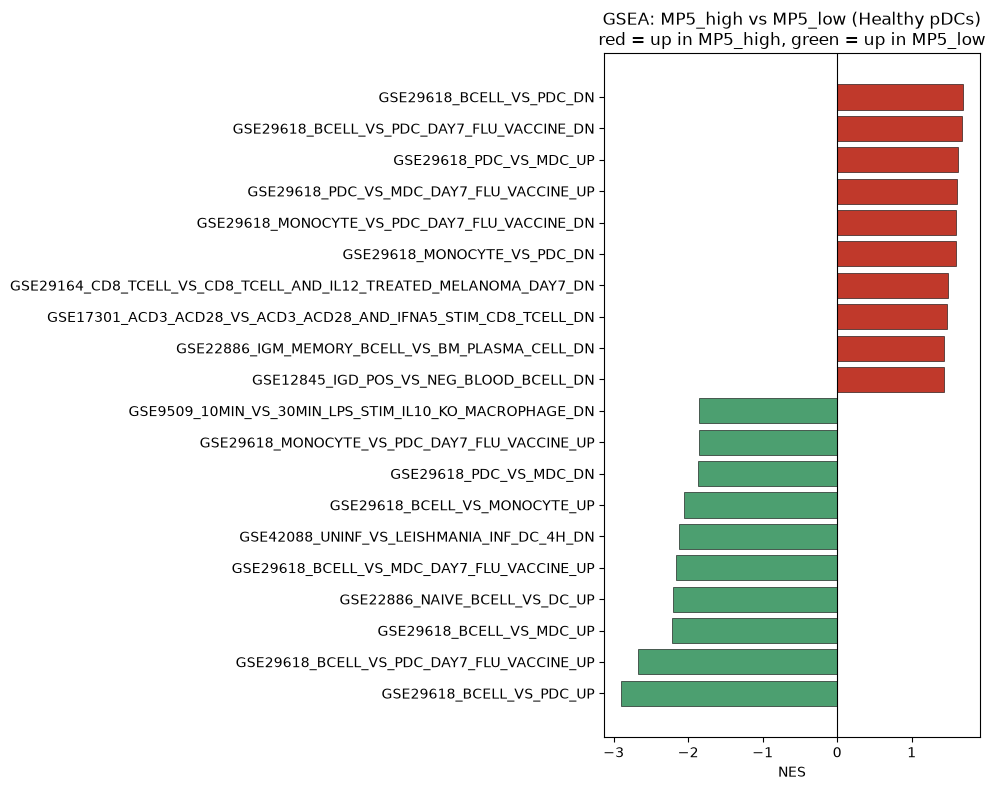

Saved barplot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_GSEA_pDC_MP5/10_09_gsea_barplot_pDC_MP5_imSig.pdf


In [22]:
colors = sig["NES"].apply(lambda x: "#C0392B" if x > 0 else "#4C9F70")  # red = up in MP5_high, green = up in MP5_low
 
fig, ax = plt.subplots(figsize=(10, 0.35 * len(sig) + 1))
ax.barh(sig["Term"], sig["NES"], color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("NES")
ax.set_title("GSEA: MP5_high vs MP5_low (Healthy pDCs)\nred = up in MP5_high, green = up in MP5_low")
fig.tight_layout()
 
out_pdf = os.path.join(GSEA_OUT_DIR, "10_09_gsea_barplot_pDC_MP5_imSig.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"Saved barplot to {out_pdf}")
 

In [43]:
# GO TERMS

# print("Top 10 by NES (positive direction, any significance):")
# print(res_df.sort_values("NES", ascending=False).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

# print("\nTop 10 by NES (negative direction, any significance):")
# print(res_df.sort_values("NES", ascending=True).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

Top 10 by NES (positive direction, any significance):
                                                                                Term      NES  FDR q-val
                 GOBP_ESTABLISHMENT_OF_PROTEIN_LOCALIZATION_TO_ENDOPLASMIC_RETICULUM 1.461851   0.383258
                                           GOBP_DETOXIFICATION_OF_INORGANIC_COMPOUND 1.458812   0.223068
GOBP_RENAL_SYSTEM_PROCESS_INVOLVED_IN_REGULATION_OF_SYSTEMIC_ARTERIAL_BLOOD_PRESSURE 1.455526   0.176658
                                                    GOBP_INTESTINAL_LIPID_ABSORPTION 1.450577   0.172666
                                                        GOBP_NEUROTRANSMITTER_UPTAKE 1.449686   0.144919
     GOBP_NEGATIVE_REGULATION_OF_FIBROBLAST_GROWTH_FACTOR_RECEPTOR_SIGNALING_PATHWAY 1.439719   0.197617
                                                       GOBP_RENAL_PROTEIN_ABSORPTION 1.437504   0.186639
                                GOBP_REGULATION_OF_SYNAPTIC_TRANSMISSION_CHOLINERGIC 1.437259   0.164681
 

In [23]:
print("Top 10 by NES (positive direction, any significance):")
print(res_df.sort_values("NES", ascending=False).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

print("\nTop 10 by NES (negative direction, any significance):")
print(res_df.sort_values("NES", ascending=True).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

Top 10 by NES (positive direction, any significance):
                                                             Term      NES  FDR q-val
                                         GSE29618_BCELL_VS_PDC_DN 1.687259        0.0
                        GSE29618_BCELL_VS_PDC_DAY7_FLU_VACCINE_DN 1.681397        0.0
                                           GSE29618_PDC_VS_MDC_UP 1.619425        0.0
                          GSE29618_PDC_VS_MDC_DAY7_FLU_VACCINE_UP 1.603842        0.0
                     GSE29618_MONOCYTE_VS_PDC_DAY7_FLU_VACCINE_DN 1.597968        0.0
                                      GSE29618_MONOCYTE_VS_PDC_DN 1.591630        0.0
GSE29164_CD8_TCELL_VS_CD8_TCELL_AND_IL12_TREATED_MELANOMA_DAY7_DN 1.493707        0.0
    GSE17301_ACD3_ACD28_VS_ACD3_ACD28_AND_IFNA5_STIM_CD8_TCELL_DN 1.474853        0.0
                   GSE22886_IGM_MEMORY_BCELL_VS_BM_PLASMA_CELL_DN 1.439840        0.0
                           GSE12845_IGD_POS_VS_NEG_BLOOD_BCELL_DN 1.433356        0.0
